# Planet demo : https://psg.gsfc.nasa.gov/index.php
'''  GJ 1214b
Geometry: GJ 1214b measured via Observatory from 14.6427 pc for date (2020/04/08 01:32 UT)
Change Object
Atmosphere and surface: Surface pressure: 1.0 bar; Molecular weight: 2.36 g/mol; Gases: H2,He,H2O,CH4; 
Surface temperature: 888.1 K; Albedo: 0.164; Emissivity: 0.836;	Change Composition
Instrument parameters: Measurement range 0.5-17 um with a resolution of 200 RP. 
Molecular signatures included; Continuum/background fluxes enabled;'''
    

In [30]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.interpolate import interp1d
from scipy.integrate import simpson


In [31]:
# Reading the file and labelling the columns for Spectral Irradiance data
df_rad = pd.read_csv('psg_rad-for-Earth-like_prototype.txt', comment='#', delim_whitespace=True).dropna() #, header=None) 
df_rad.columns = ['Wave/freq', 'Total', 'Noise', 'Stellar', 'Earth-like-Prototype']


In [32]:
print (df_rad)  # To display the data and the column variables

     Wave/freq         Total  Noise    Stellar  Earth-like-Prototype
0     0.502500  6.920303e+04    inf  2035720.0          1.365290e-10
1     0.505012  6.997137e+04    inf  2055720.0          1.544530e-10
2     0.507538  7.610681e+04    inf  2075670.0          1.746660e-10
3     0.510075  8.694440e+04    inf  2095570.0          1.974410e-10
4     0.512626  9.537187e+04    inf  2115410.0          2.229970e-10
..         ...           ...    ...        ...                   ...
702  16.661397  4.243758e+09    inf    48108.7          4.243760e+09
703  16.744704  4.282728e+09    inf    47649.2          4.282730e+09
704  16.828428  4.566885e+09    inf    47194.1          4.566890e+09
705  16.912570  4.838565e+09    inf    46743.2          4.838560e+09
706  16.997133  5.137148e+09    inf    46296.6          5.137150e+09

[707 rows x 5 columns]


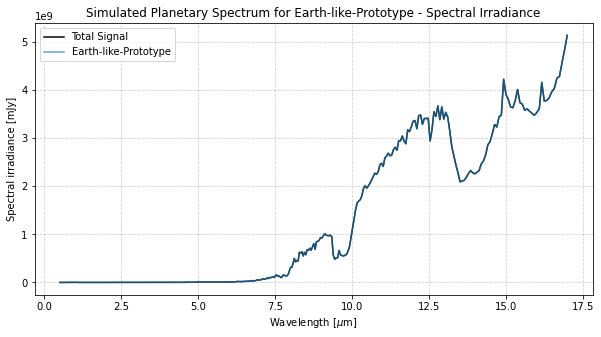

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(df_rad['Wave/freq'], df_rad['Total'], label='Total Signal', color='black', linewidth=1.5)
plt.plot(df_rad['Wave/freq'], df_rad['Earth-like-Prototype'], label='Earth-like-Prototype', alpha=0.7)
#plt.plot(df_rad['Wave/freq'], df_rad['Transit'], label='Transit', alpha=0.7)



plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Spectral irradiance [mJy]') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Spectral Irradiance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

My understanding of throughput and convolution:



In [56]:
def convolve_with_throughput(wavelength, spectrum, thr_wave, thr_val):
   interp_thr = interp1d(thr_wave, thr_val, bounds_error=False, fill_value=0.0)
   T = interp_thr(wavelength)
   numerator = simpson(spectrum * T, wavelength)
   denominator = simpson(T, wavelength)
   if denominator == 0:
       return np.nan
   return numerator / denominator


In [61]:
wavelength = df_rad['Wave/freq'].values*10e3  # converted to nm
spectrum = df_rad['Stellar'].values
spectrum2 = df_rad['Earth-like-Prototype'].values

# Wavelength range for PLATO Normal Cameras (nm) micrometers
thr_wave = np.linspace(5025, 169971.33, 707)

#For throughput values at 60% in PLATO cameras following the gaussian formula , values in nm nanometers
thr_val = 0.6 * np.exp(-((thr_wave - 650)**2) / (2 * 200**2)) 

In [62]:
Stellar_convolved = convolve_with_throughput(wavelength, spectrum, thr_wave, thr_val)
Planet_convolved = convolve_with_throughput(wavelength, spectrum2, thr_wave, thr_val)

print(f"Convolved Stellar Flux: {Stellar_convolved}")
print(f"Convolved Planet Flux: {Planet_convolved}")

Convolved Stellar Flux: 2101281.207075146
Convolved Planet Flux: 2.109612692497999e-10


In [63]:
print(f"Data Wavelength Range: {wavelength.min():.2f} to {wavelength.max():.2f} nm")
print(f"Throughput Range:      {thr_wave.min():.2f} to {thr_wave.max():.2f} nm")

# Check if they overlap at all
overlap = (wavelength.max() > thr_wave.min()) and (wavelength.min() < thr_wave.max())
print(f"Do they overlap?:      {overlap}")

Data Wavelength Range: 5025.00 to 169971.33 nm
Throughput Range:      5025.00 to 169971.33 nm
Do they overlap?:      True
